In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('adult_with_headers.csv')

In [3]:
df.shape

(32561, 15)

In [4]:
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [5]:
### checking missing values
df.isnull().sum().sum()/len(df)*100

np.float64(0.0)

In [6]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(24)

In [8]:
df[df.duplicated()]

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
4881,25,Private,308144,Bachelors,13,Never-married,Craft-repair,Not-in-family,White,Male,0,0,40,Mexico,<=50K
5104,90,Private,52386,Some-college,10,Never-married,Other-service,Not-in-family,Asian-Pac-Islander,Male,0,0,35,United-States,<=50K
9171,21,Private,250051,Some-college,10,Never-married,Prof-specialty,Own-child,White,Female,0,0,10,United-States,<=50K
11631,20,Private,107658,Some-college,10,Never-married,Tech-support,Not-in-family,White,Female,0,0,10,United-States,<=50K
13084,25,Private,195994,1st-4th,2,Never-married,Priv-house-serv,Not-in-family,White,Female,0,0,40,Guatemala,<=50K
15059,21,Private,243368,Preschool,1,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,50,Mexico,<=50K
17040,46,Private,173243,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,<=50K
18555,30,Private,144593,HS-grad,9,Never-married,Other-service,Not-in-family,Black,Male,0,0,40,?,<=50K
18698,19,Private,97261,HS-grad,9,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,40,United-States,<=50K
21318,19,Private,138153,Some-college,10,Never-married,Adm-clerical,Own-child,White,Female,0,0,10,United-States,<=50K


In [9]:
df.drop_duplicates(inplace=True,ignore_index=True)

In [10]:
### scaling
from sklearn.preprocessing import StandardScaler,MinMaxScaler

In [12]:
num_features = ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']

In [13]:
std_sca=StandardScaler()
min_max=MinMaxScaler()

In [15]:
std_sca.fit_transform(df[num_features])

array([[ 0.03038995, -1.06356884,  1.13477712,  0.14829174, -0.21674317,
        -0.03566374],
       [ 0.8369732 , -1.00866848,  1.13477712, -0.14597544, -0.21674317,
        -2.22248299],
       [-0.0429358 ,  0.24503992, -0.42067868, -0.14597544, -0.21674317,
        -0.03566374],
       ...,
       [ 1.42357919, -0.35877886, -0.42067868, -0.14597544, -0.21674317,
        -0.03566374],
       [-1.2161478 ,  0.11092955, -0.42067868, -0.14597544, -0.21674317,
        -1.65552985],
       [ 0.9836247 ,  0.92981187, -0.42067868,  1.88763548, -0.21674317,
        -0.03566374]])

In [16]:
min_max.fit_transform(df[num_features])

array([[0.30136986, 0.0443019 , 0.8       , 0.02174022, 0.        ,
        0.39795918],
       [0.45205479, 0.0482376 , 0.8       , 0.        , 0.        ,
        0.12244898],
       [0.28767123, 0.13811345, 0.53333333, 0.        , 0.        ,
        0.39795918],
       ...,
       [0.56164384, 0.09482688, 0.53333333, 0.        , 0.        ,
        0.39795918],
       [0.06849315, 0.12849934, 0.53333333, 0.        , 0.        ,
        0.19387755],
       [0.47945205, 0.18720338, 0.53333333, 0.1502415 , 0.        ,
        0.39795918]])

In [17]:
### we use standard scalar when the data roughly follows a normal distribution or when features centered around 0
### we use minmaxscalar when we want to rescale features to specific range [0,1] 

In [18]:
# Separate numerical and categorical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)

Numerical Columns: ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']
Categorical Columns: ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country', 'income']


In [19]:
# Count unique values in each categorical column
for col in cat_cols:
    print(f"{col}: {df[col].nunique()} unique values")

workclass: 9 unique values
education: 16 unique values
marital_status: 7 unique values
occupation: 15 unique values
relationship: 6 unique values
race: 5 unique values
sex: 2 unique values
native_country: 42 unique values
income: 2 unique values


In [20]:
from sklearn.preprocessing import OneHotEncoder,LabelEncoder

In [21]:
lab_enc=LabelEncoder()
one_hot_enc=OneHotEncoder()

In [22]:
one_hot_cols = [col for col in cat_cols if df[col].nunique() < 5]
df_onehot = pd.get_dummies(df, columns=one_hot_cols, drop_first=True)

In [24]:
label_cols = [col for col in cat_cols if df[col].nunique() >= 5]
for col in label_cols:
    df_onehot[col] = lab_enc.fit_transform(df_onehot[col])

In [25]:
print(df_onehot.head())

   age  workclass  fnlwgt  education  education_num  marital_status  \
0   39          7   77516          9             13               4   
1   50          6   83311          9             13               2   
2   38          4  215646         11              9               0   
3   53          4  234721          1              7               2   
4   28          4  338409          9             13               2   

   occupation  relationship  race  capital_gain  capital_loss  hours_per_week  \
0           1             1     4          2174             0              40   
1           4             0     4             0             0              13   
2           6             1     4             0             0              40   
3           6             0     2             0             0              40   
4          10             5     2             0             0              40   

   native_country  sex_ Male  income_ >50K  
0              39       True         Fals

In [27]:
df_onehot.dtypes

age               int64
workclass         int64
fnlwgt            int64
education         int64
education_num     int64
marital_status    int64
occupation        int64
relationship      int64
race              int64
capital_gain      int64
capital_loss      int64
hours_per_week    int64
native_country    int64
sex_ Male          bool
income_ >50K       bool
dtype: object

In [28]:
df_onehot.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
sex_ Male         0
income_ >50K      0
dtype: int64

In [29]:
### one hot encoding
### pros
### it preserves the nominal nature of categorical variables,it is safe for linear models,it is widely used.
### cons
### increases dimensionality,more columns mean more memory usage,many zeros in the dataset can slow some algorithms

In [30]:
### label encoding
### pros
### memory efficient,simple and fast,good for tree based models
### cons
### implies an order that may not exist,not suitable for distance based models

In [31]:
df['work_hours_per_year'] = df['hours_per_week'] * 52

In [32]:
df['capital_net_gain'] = df['capital_gain'] - df['capital_loss']

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

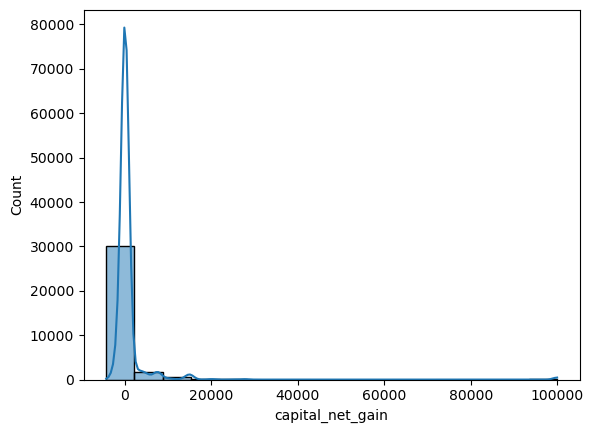

In [35]:
sns.histplot(df['capital_net_gain'], kde=True)
plt.show()

In [36]:
### new feature
### work_hours_per_year -- captures annual effort,correlates with income
### capital_net_gain -- represents net financial gain,reduces redundancy

In [38]:
df['capital_gain_log'] = np.log1p(df['capital_gain'])

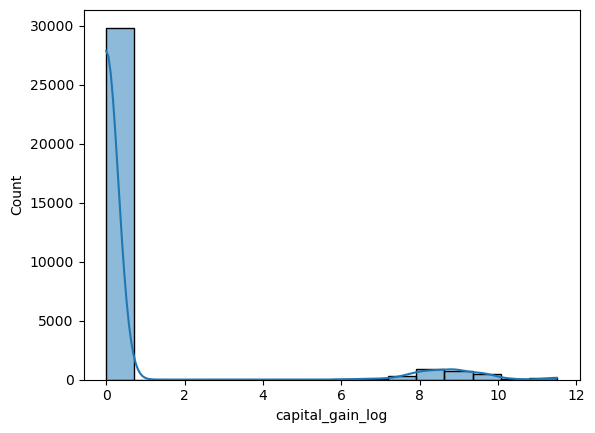

In [39]:
sns.histplot(df['capital_gain_log'], kde=True)
plt.show()

In [40]:
### capital_gain_log -- reduces skewness